# Mestrado em Inteligência Artificial 25/26

# Practical 2 - Markov Decision Processes (MDPs) with Gridworld - Solutions

What's the optimal behaviour?

> The optimal behaviour is to reach a terminal in as few steps as possible.

## Imports

In [1]:
import sys
from pathlib import Path

# Add repo root to path so mia_rl package is importable
REPO_ROOT = Path().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

In [2]:
from mia_rl.envs.mdp_gridworld import MDP_Gridworld, TrapGridworld, ACTIONS
from mia_rl.agents.planning.mdp_gridworld import (
    zeros_V,
    zeros_Q,
    uniform_random_policy,
    bellman_expectation_update,
    bellman_optimality_update,
    policy_evaluation,
    policy_evaluation_with_history,
    policy_evaluation_Q,
    greedy_policy_from_V,
    policy_improvement,
    policy_iteration,
    value_iteration,
    value_iteration_stochastic,
)
from mia_rl.plots.mdp_gridworld import (
    plot_grid,
    plot_policy_iteration_history,
    plot_policy_evaluation_history,
)

## 1) Gridworld MDP

We define:
- **States**: cells $(r,c)$
- **Actions**: `U, D, L, R`
- **Transition**: deterministic (attempted move; if off-grid you stay)
- **Reward**: -1 each step; terminal states end the episode

`env.step(state, action)` returns: `next_state, reward, done_flag`

The environment is defined in `mia_rl/envs/mdp_gridworld.py` as `MDP_Gridworld`.

In [3]:
env = MDP_Gridworld()
env.states()[:5], env.terminal_states

([(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)], ((0, 0), (3, 3)))

### Quick sanity checks

In [4]:
# From a non-terminal, moving into a wall keeps you in place but still costs -1
print("From (0,1) with U:", env.step((0,1), "U"))
# From a non-terminal, moving toward terminal
print("From (0,1) with L:", env.step((0,1), "L"))
# From terminal, stay terminal
print("From (0,0) with R:", env.step((0,0), "R"))

From (0,1) with U: ((0, 1), -1.0, False)
From (0,1) with L: ((0, 0), -1.0, True)
From (0,0) with R: ((0, 0), 0.0, True)


## 2) Utilities: indexing states and initializing V

We'll store $V$ as a 2D array `V[r,c]`.

In [5]:
V0 = zeros_V(env)
V0

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 3) Policy definition

We start with a **uniform random policy**:
$\pi(a\mid s)=\frac{1}{4}$ for all non-terminal states.

In [6]:
policy = uniform_random_policy(env)
policy[(1,1)]

{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

## 4) Policy Evaluation (compute $V^{\pi}$)

Bellman expectation backup:

$$V(s) \leftarrow \sum_a \pi(a|s)\left[r(s,a) + \gamma V(s')\right]$$

Implemented in `mia_rl/agents/planning/mdp_gridworld.py`:
- `bellman_expectation_update` - backup para um estado
- `policy_evaluation` - avaliacao iterativa ate convergencia

In [7]:
gamma = 0.9
V_pi, iters = policy_evaluation(env, policy, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters)
V_pi

Converged in iterations: 118


array([[ 0.   , -5.278, -7.128, -7.651],
       [-5.278, -6.606, -7.181, -7.128],
       [-7.128, -7.181, -6.606, -5.278],
       [-7.651, -7.128, -5.278,  0.   ]])

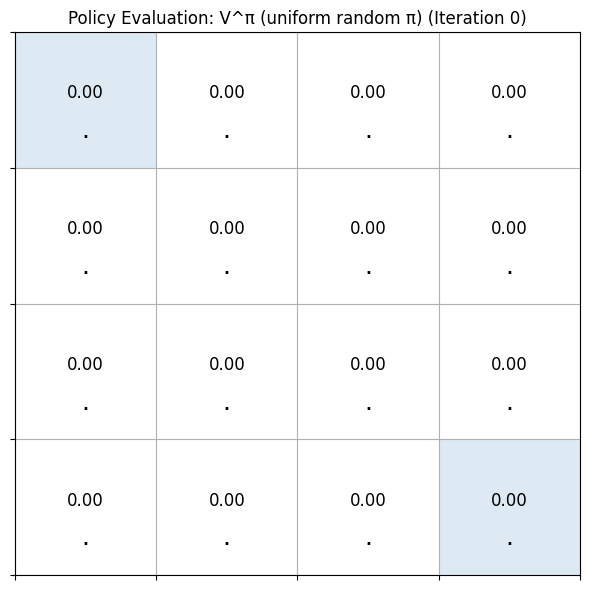

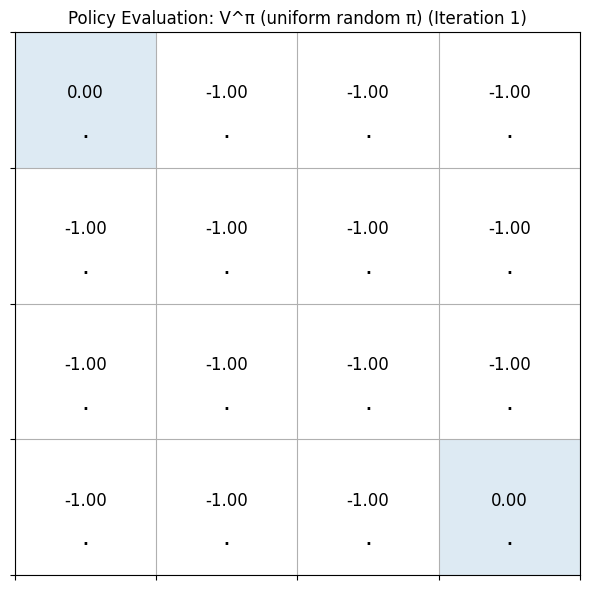

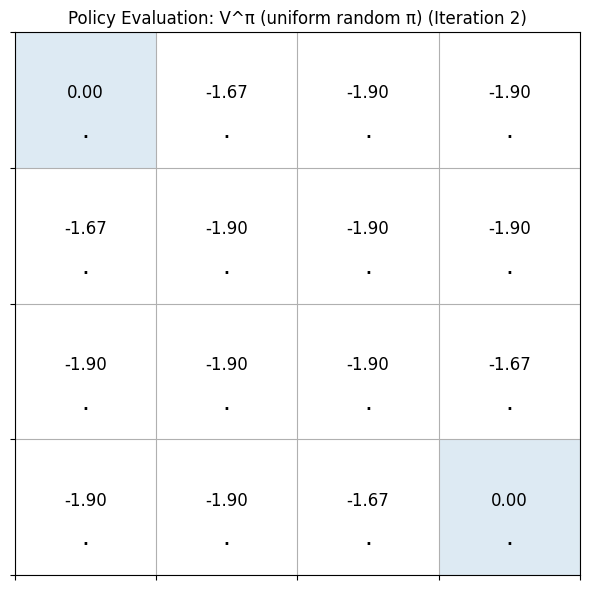

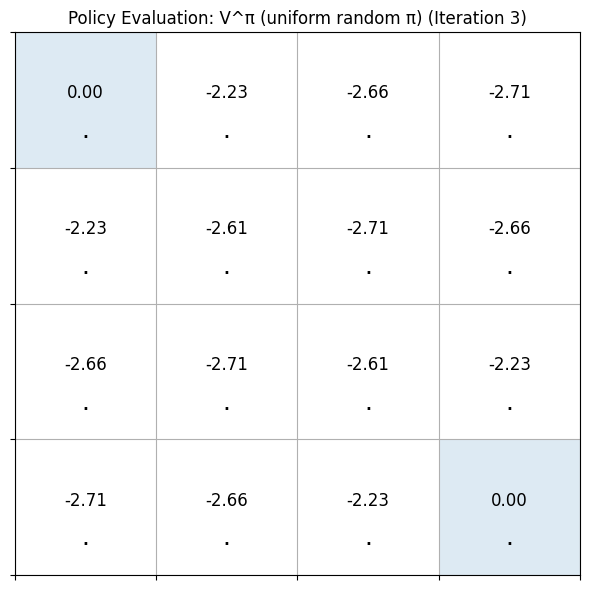

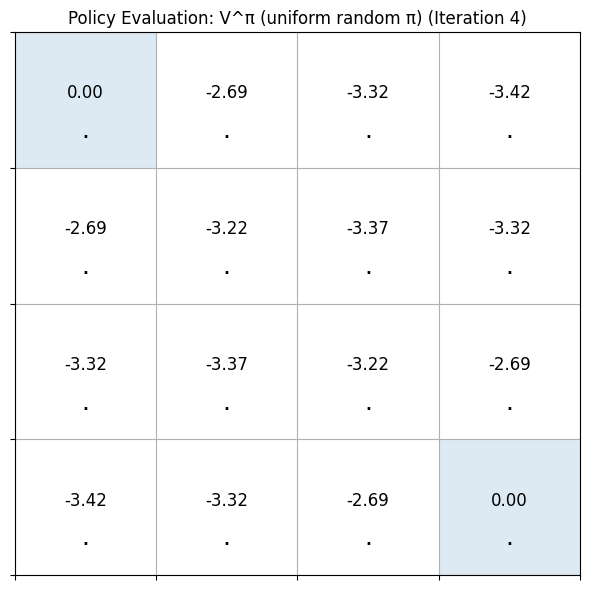

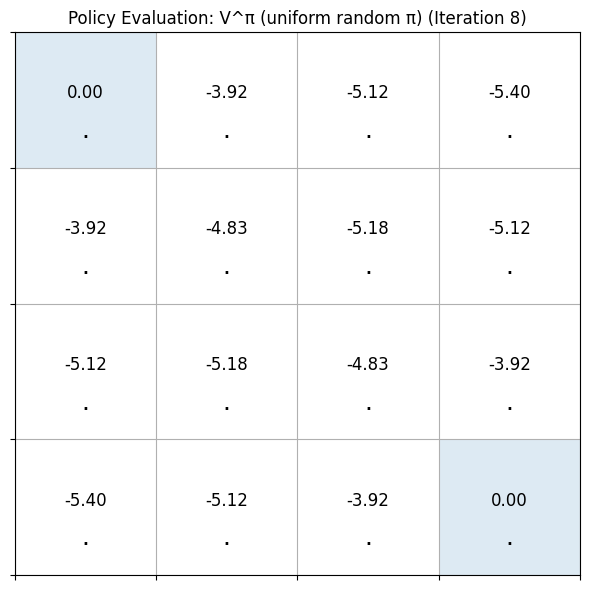

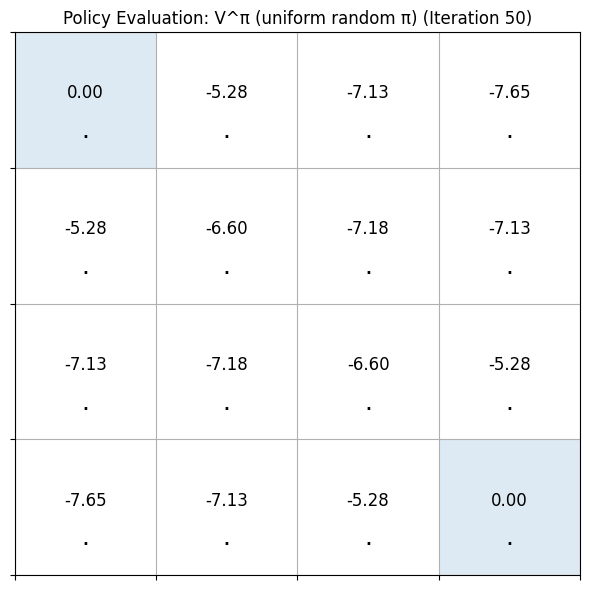

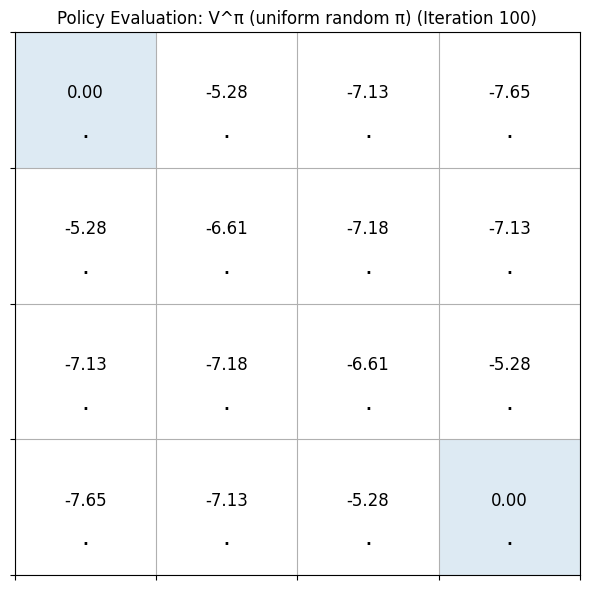

In [8]:
# Policy evaluation with history -- snapshots at specific iterations
V_pi_hist, it_pi_hist = policy_evaluation_with_history(env, policy, gamma=gamma, theta=1e-8)
plot_policy_evaluation_history(env, V_pi_hist, it_pi_hist)

## 5) Value Iteration (approximate $V^{*}$)

Bellman optimality backup:

$$V(s) \leftarrow \max_a \left[r(s,a) + \gamma V(s')\right]$$

We then extract a greedy policy:
$\pi(s)=\arg\max_a\,[r(s,a)+\gamma V(s')]$

In [9]:
V_star, iters_vi = value_iteration(env, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters_vi)
V_star

Converged in iterations: 4


array([[ 0.  , -1.  , -1.9 , -2.71],
       [-1.  , -1.9 , -2.71, -1.9 ],
       [-1.9 , -2.71, -1.9 , -1.  ],
       [-2.71, -1.9 , -1.  ,  0.  ]])

In [10]:
pi_star = greedy_policy_from_V(env, V_star, gamma=gamma)
pi_star[(2,2)], pi_star[(0,1)], pi_star[(1,0)]

('D', 'L', 'U')

In [11]:
pi_star

{(0, 0): '·',
 (0, 1): 'L',
 (0, 2): 'L',
 (0, 3): 'D',
 (1, 0): 'U',
 (1, 1): 'U',
 (1, 2): 'U',
 (1, 3): 'D',
 (2, 0): 'U',
 (2, 1): 'U',
 (2, 2): 'D',
 (2, 3): 'D',
 (3, 0): 'U',
 (3, 1): 'R',
 (3, 2): 'R',
 (3, 3): '·'}

## 5.5) Compute the action-value function $Q^{\pi}$

So far, we computed **state-value functions**.
We now introduce the **action-value function**.

For a deterministic environment, the Bellman expectation equation for $Q^{\pi}$ is:

$$Q^{\pi}(s,a) = r(s,a) + \gamma \sum_{a'} \pi(a'\mid s')\,Q^{\pi}(s',a')$$

where $(s', r, done) = \texttt{step}(s,a)$.

We verify: $V^{\pi}(s) = \sum_a \pi(a\mid s)\,Q^{\pi}(s,a)$

In [12]:
Q_pi, itq = policy_evaluation_Q(env, policy, gamma=gamma, theta=1e-8)
print("Q^pi converged in iterations:", itq)

# Verify V^pi(s) = sum_a pi(a|s) Q^pi(s,a)
V_from_Q = zeros_V(env)
for (r, c) in env.states():
    s = (r, c)
    if env.is_terminal(s):
        V_from_Q[r, c] = 0.0
    else:
        V_from_Q[r, c] = sum(
            policy[s][a] * Q_pi[r, c, a_index]
            for a_index, a in enumerate(ACTIONS)
        )

print("max |V_pi - V_from_Q| =", np.max(np.abs(V_pi - V_from_Q)))

Q^pi converged in iterations: 118
max |V_pi - V_from_Q| = 0.0


## 6) Visualization

We will visualize:
- The value function as numbers inside the grid
- A policy as arrows

This is the part that makes Bellman backups click.

Implemented in `mia_rl/plots/mdp_gridworld.py` as `plot_grid`.

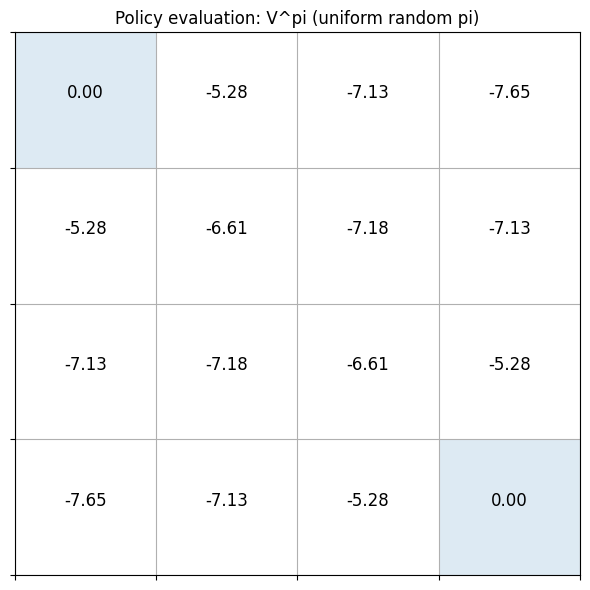

In [13]:
plot_grid(env, V_pi, title="Policy evaluation: V^pi (uniform random pi)")
plt.show()

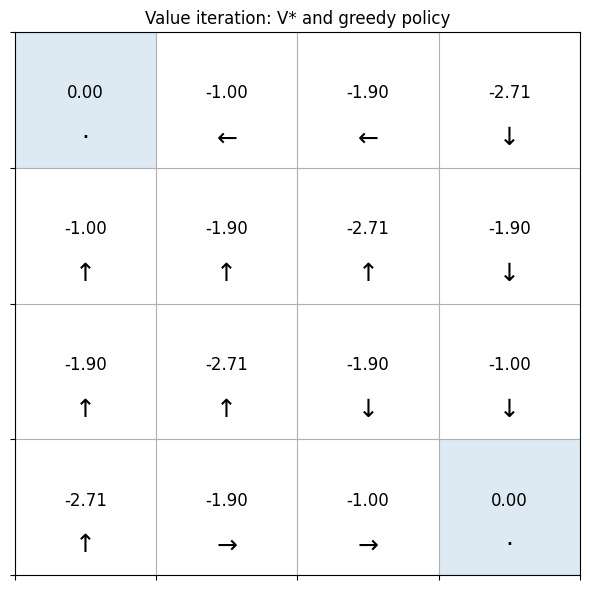

In [14]:
plot_grid(env, V_star, policy=pi_star, title="Value iteration: V* and greedy policy")
plt.show()

Given that both terminal states are equally far from (3,0) and (0,3), why does the optimal policy move vertically rather than horizontally in those states?

## 7) Exercises

### Exercise A -- Change gamma and observe
Try `gamma = 0.5` and `gamma = 0.99`. Re-run policy evaluation and value iteration.
What changes in the value magnitude and the implied behaviour?

### Exercise B -- Add a trap cell
Pick a cell, e.g. (0,2), and make stepping into it give reward -10.
How does the optimal policy change? Tip: Use the `TrapGridworld` class from `mia_rl/envs/mdp_gridworld.py`.

### Exercise C -- Make the environment stochastic
Modify `env.step` so that with probability 0.8 the intended action happens, and with probability 0.1 you slip left/right.
What changes in V* and the greedy policy?

## 8) Solutions to the Exercises

### Exercise A -- Changing gamma
- Smaller gamma (e.g., 0.5): the agent values the future less, so **magnitudes shrink** (less negative far away).
  The direction of the optimal policy is usually unchanged (still shortest path), but values drop off faster.
- Larger gamma (e.g., 0.99): the agent values long-term rewards more, so **magnitudes grow** (more negative far away).

### Exercise B -- Trap cell with -10 on entry
The optimal policy will tend to **route around** the trap, even if that takes extra steps, depending on gamma.
With high gamma, avoiding the trap is even more important.

### Exercise C -- Stochastic slip
Adding slip makes outcomes uncertain. Values typically become **more negative** (mistakes cost steps).
The optimal policy may become more cautious near terminals or traps.

Gamma = 0.5 (value iteration iters=4)


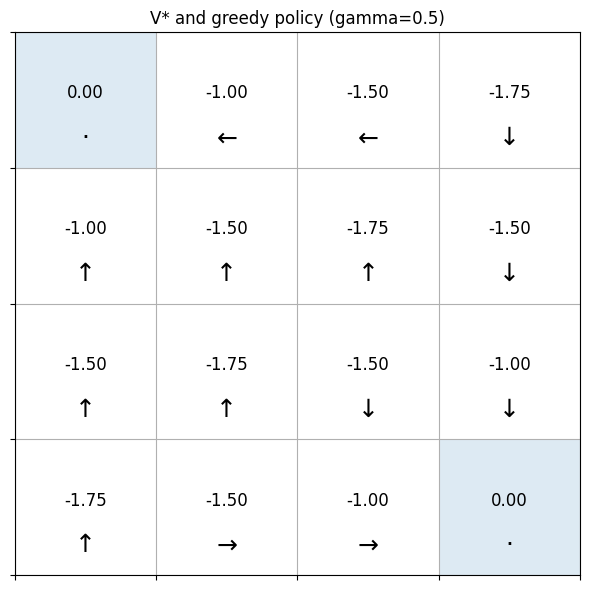

Gamma = 0.9 (value iteration iters=4)


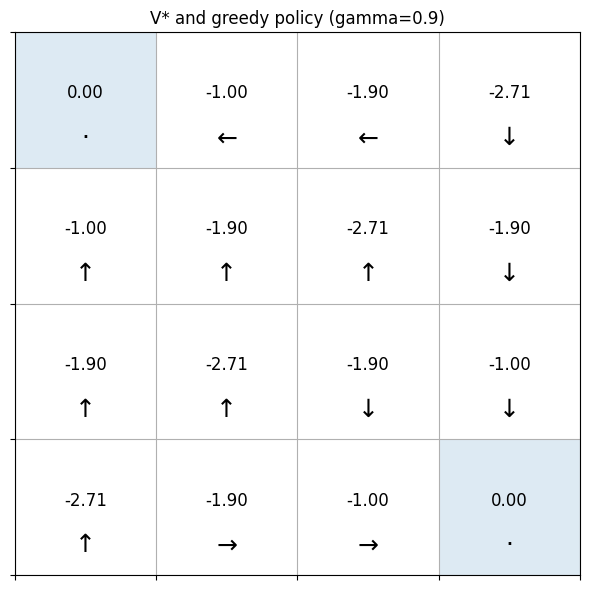

Gamma = 0.99 (value iteration iters=4)


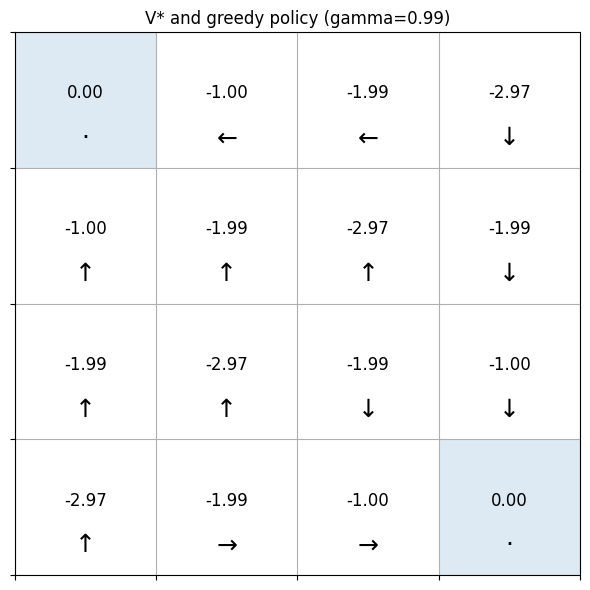

In [15]:
# Exercise A: compare gammas
for g in [0.5, 0.9, 0.99]:
    Vg, itg = value_iteration(env, gamma=g, theta=1e-8)
    pig = greedy_policy_from_V(env, Vg, gamma=g)
    print(f"Gamma = {g} (value iteration iters={itg})")
    plot_grid(env, Vg, policy=pig, title=f"V* and greedy policy (gamma={g})")
    plt.show()

Trap value iteration iters: 4


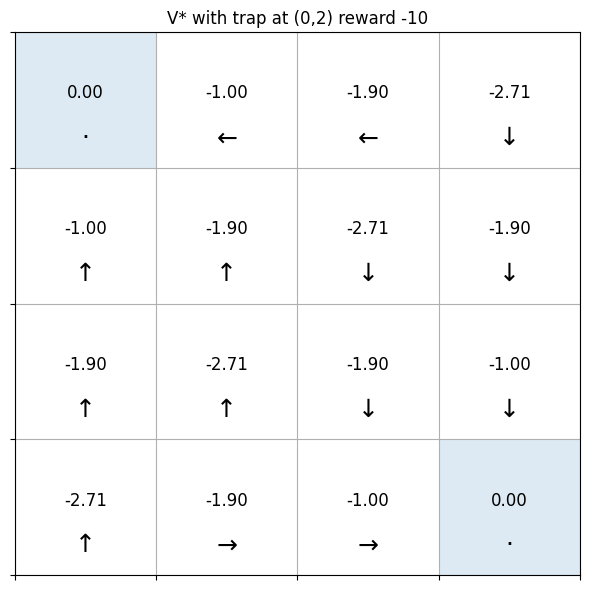

In [16]:
# Exercise B: trap cell with -10 on entry (uses TrapGridworld from envs)
env_trap = TrapGridworld()
V_trap, it_trap = value_iteration(env_trap, gamma=0.90, theta=1e-8)
pi_trap = greedy_policy_from_V(env_trap, V_trap, gamma=0.90)
print("Trap value iteration iters:", it_trap)
plot_grid(env_trap, V_trap, policy=pi_trap, title="V* with trap at (0,2) reward -10")
plt.show()

Stochastic value iteration iters: 25


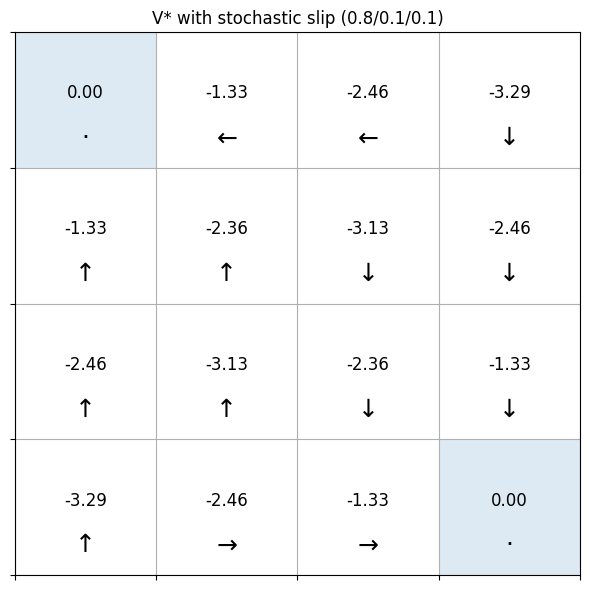

In [17]:
# Exercise C: stochastic slip (0.8 intended, 0.1 left/right)
V_stoch, its = value_iteration_stochastic(env, gamma=0.9, theta=1e-8)
pi_stoch = greedy_policy_from_V(env, V_stoch, gamma=0.9)
print("Stochastic value iteration iters:", its)
plot_grid(env, V_stoch, policy=pi_stoch, title="V* with stochastic slip (0.8/0.1/0.1)")
plt.show()